# 13 — Teste de Multijanelas Temporais

## Objetivo

Avaliar se a forma de representar as 24 horas anteriores melhora o modelo atual.

Referência mantida:

- gap de sequência: 900s;
- observação total: 24h;
- horizonte: 8h;
- modelo: Random Forest;
- split temporal: treino até abril, validação em maio, teste em junho;
- target: início de pelo menos um episódio futuro contendo `Is_Dont_Go = 1`.

## Pergunta investigativa

O notebook 12 mostrou que `900s + 24h/8h + IDs + conceitos textuais` reduz falsos positivos contra o
baseline histórico, mas ainda perde um pouco de recall e não aprende escavadeiras. Este notebook testa
se a informação de recência dentro das 24h anteriores ajuda:

1. referência agregada 24h: soma tudo nas 24h, como no notebook 12;
2. multijanela core: separa contagens gerais em 0-8h, 8-16h e 16-24h, mantendo IDs/conceitos agregados;
3. multijanela completa: separa também IDs e conceitos por bucket de 8h;
4. multijanela com deltas: adiciona diferenças e razões simples entre buckets recentes e antigos.

## Limites

- `Is_Dont_Go` continua sendo target provisório, não falha confirmada;
- nenhuma decisão deve ser tomada apenas pelo melhor resultado no teste;
- se o notebook pesar localmente, manter a estrutura e executar fora do Codex antes de refatorar por
  desempenho;
- custos de parada/manutenção ainda não entram nesta etapa.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

GAP_S = 900
OBSERVATION_HOURS = 24
HORIZON_HOURS = 8
BUCKET_HOURS = 8
TOP_ALARM_IDS = 200
TOP_TEXT_CONCEPTS = 200

LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

print(f"Raiz do projeto: {ROOT}")
print(f"Configuração: gap={GAP_S}s, observação={OBSERVATION_HOURS}h, horizonte={HORIZON_HOURS}h")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Configuração: gap=900s, observação=24h, horizonte=8h


## 1. Camada analítica congelada

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

base_audit = query(
    '''
    SELECT
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo - 1) AS duplicatas_retiradas,
        sum(Is_Dont_Go) AS linhas_dont_go
    FROM analytic_events
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,tempo_s
0,35608094,265564.0,19941.0,19.2


## 2. Sequências e catálogo de conceitos

In [3]:
def build_sequences():
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_sequences AS
        WITH ordered AS (
            SELECT *,
                   lag(Data_Evento) OVER (
                       PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ) AS evento_anterior
            FROM analytic_events
        ), flagged AS (
            SELECT *,
                   CASE
                       WHEN evento_anterior IS NULL THEN 1
                       WHEN date_diff('millisecond', evento_anterior, Data_Evento) > {GAP_S * 1000} THEN 1
                       ELSE 0
                   END AS nova_sequencia
            FROM ordered
        ), numbered AS (
            SELECT *,
                   sum(nova_sequencia) OVER (
                       PARTITION BY TAG, Id_Alarme
                       ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ) AS numero_sequencia
            FROM flagged
        )
        SELECT
            TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
            Id_Alarme, any_value(Alarme) AS Alarme,
            numero_sequencia,
            min(Data_Evento) AS inicio,
            max(Data_Evento) AS fim,
            time_bucket(INTERVAL '8 hours', min(Data_Evento)) AS bin_start,
            date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
            count(*) AS registros_analiticos,
            sum(ids_evento_no_grupo) AS registros_brutos_representados,
            max(Is_Dont_Go) AS is_dont_go,
            max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
            max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
            max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
            max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
        FROM numbered
        GROUP BY TAG, Id_Alarme, numero_sequencia
        '''
    )
    return query(
        '''
        SELECT
            count(*) AS sequencias,
            sum(is_dont_go) AS sequencias_dont_go,
            avg(registros_analiticos) AS registros_por_sequencia_media,
            max(registros_analiticos) AS maior_sequencia
        FROM alarm_sequences
        '''
    )

def create_catalog():
    catalog = query(
        '''
        SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias
        FROM alarm_sequences
        GROUP BY 1
        ORDER BY sequencias DESC
        '''
    )
    catalog["conceito_textual"] = catalog["Alarme"].map(normalize_alarm_name)
    con.register("alarm_concepts", catalog[["Id_Alarme", "conceito_textual"]])
    return catalog

seq_audit = build_sequences()
catalog = create_catalog()
display(seq_audit)
display(catalog.head(20))

,sequencias,sequencias_dont_go,registros_por_sequencia_media,maior_sequencia
0,979994,7572.0,36.335012,32721


,Id_Alarme,Alarme,sequencias,conceito_textual
0,84626979,Body Up,90981,BODY UP
1,84626978,Cycle,90769,CYCLE
2,84626977,Load,90084,LOAD
3,84626976,Dipper,88149,DIPPER
4,84672480,Oem Interface Timeout,43005,OEM INTERFACE TIMEOUT
5,84672481,Oem Interface Normal,39503,OEM INTERFACE NORMAL
6,84612807,Payload Overload - Active,29745,PAYLOAD OVERLOAD ACTIVE
7,84612806,Payload Overload - Inactive,29037,PAYLOAD OVERLOAD INACTIVE
8,1074008238,Engine At High Throttle,13821,ENGINE AT HIGH THROTTLE
9,1074008239,Engine At High Throttle For 3Min,13406,ENGINE AT HIGH THROTTLE FOR 3MIN


## 3. Amostras, buckets e features base

In [4]:
def build_sample_grid():
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE sample_grid AS
        WITH tags AS (
            SELECT DISTINCT TAG FROM analytic_events
        ), prediction_bins AS (
            SELECT * FROM generate_series(
                TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{OBSERVATION_HOURS} hours',
                TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{HORIZON_HOURS} hours',
                INTERVAL '8 hours'
            ) AS t(prediction_time)
        )
        SELECT
            row_number() OVER () AS sample_id,
            tags.TAG,
            prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' AS feature_start,
            prediction_time,
            prediction_time + INTERVAL '{HORIZON_HOURS} hours' AS target_end
        FROM tags CROSS JOIN prediction_bins
        WHERE prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' >= TIMESTAMP '2025-01-01 00:00:00'
        '''
    )

def build_sequence_bins():
    con.execute(
        '''
        CREATE OR REPLACE TEMP TABLE sequence_bins AS
        SELECT
            TAG, bin_start,
            count(*) AS sequencias_total,
            count(DISTINCT Id_Alarme) AS alarmes_distintos,
            sum(registros_analiticos) AS registros_analiticos,
            sum(registros_brutos_representados) AS registros_brutos_representados,
            sum(duracao_ms) AS duracao_soma_ms,
            max(duracao_ms) AS duracao_max_ms,
            max(registros_analiticos) AS maior_sequencia_registros,
            sum(possui_critico) AS sequencias_com_critico,
            sum(possui_activate) AS sequencias_com_activate,
            sum(possui_inactive) AS sequencias_com_inactive,
            sum(possui_classe_nula) AS sequencias_com_classe_nula,
            sum(is_dont_go) AS episodios_dont_go
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )

def build_samples():
    samples = query(
        f'''
        WITH feature_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.sequencias_total), 0) AS sequencias_total,
                coalesce(sum(b.alarmes_distintos), 0) AS alarmes_distintos,
                coalesce(sum(b.registros_analiticos), 0) AS registros_analiticos,
                coalesce(sum(b.registros_brutos_representados), 0) AS registros_brutos_representados,
                CASE
                    WHEN coalesce(sum(b.sequencias_total), 0) > 0
                    THEN coalesce(sum(b.duracao_soma_ms), 0) / sum(b.sequencias_total)
                    ELSE 0
                END AS duracao_media_ms,
                coalesce(max(b.duracao_max_ms), 0) AS duracao_max_ms,
                coalesce(max(b.maior_sequencia_registros), 0) AS maior_sequencia_registros,
                coalesce(sum(b.sequencias_com_critico), 0) AS sequencias_com_critico,
                coalesce(sum(b.sequencias_com_activate), 0) AS sequencias_com_activate,
                coalesce(sum(b.sequencias_com_inactive), 0) AS sequencias_com_inactive,
                coalesce(sum(b.sequencias_com_classe_nula), 0) AS sequencias_com_classe_nula
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.feature_start
             AND b.bin_start < g.prediction_time
            GROUP BY 1
        ), target_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.episodios_dont_go), 0) AS episodios_dont_go_target
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.prediction_time
             AND b.bin_start < g.target_end
            GROUP BY 1
        )
        SELECT
            g.sample_id, g.TAG, g.feature_start, g.prediction_time, g.target_end,
            f.* EXCLUDE(sample_id),
            y.episodios_dont_go_target,
            CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
            CASE
                WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
                 AND g.target_end > TIMESTAMP '{MISSING_START}'
                THEN 0 ELSE 1
            END AS amostra_valida
        FROM sample_grid g
        JOIN feature_agg f USING(sample_id)
        JOIN target_agg y USING(sample_id)
        ORDER BY g.prediction_time, g.TAG
        '''
    )
    samples = samples[samples["amostra_valida"] == 1].copy()
    tag_profile = query(
        '''
        SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
        FROM analytic_events
        GROUP BY 1
        '''
    )
    samples = samples.merge(tag_profile, how="left", on="TAG")
    samples = samples.assign(split=np.select(
        [
            samples["prediction_time"] < pd.Timestamp("2025-05-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-31"),
            samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
        ],
        ["treino", "validacao", "teste"],
        default="fora_do_split",
    ))
    return samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

def add_base_features(samples):
    samples = pd.concat([
        samples,
        pd.DataFrame({
            "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
            "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
            "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        }, index=samples.index)
    ], axis=1).copy()
    return samples, [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive",
        "sequencias_com_classe_nula", "feature_has_events",
        "prediction_hour_sin", "prediction_hour_cos",
        "prediction_dow_sin", "prediction_dow_cos",
    ]

build_sample_grid()
build_sequence_bins()
samples = build_samples()
samples, base_features = add_base_features(samples)
display(samples.groupby(["split", "Tipo"], dropna=False).agg(
    amostras=("target", "size"),
    positivas=("target", "sum"),
    prevalencia=("target", "mean"),
).reset_index())

,split,Tipo,amostras,positivas,prevalencia
0,teste,Caminhao,2610,283,0.108429
1,teste,Escavadeira,435,2,0.004598
2,treino,Caminhao,10710,1895,0.176937
3,treino,Escavadeira,1785,15,0.008403
4,validacao,Caminhao,2700,280,0.103704
5,validacao,Escavadeira,450,7,0.015556


## 4. Features agregadas e multijanelas

In [5]:
def sql_literal(value):
    return "'" + str(value).replace("'", "''") + "'"

def add_aggregate_id_features(samples):
    top_ids = query(
        f'''
        SELECT Id_Alarme, count(*) AS sequencias
        FROM alarm_sequences
        WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, Id_Alarme
        LIMIT {TOP_ALARM_IDS}
        '''
    )["Id_Alarme"].astype(int).tolist()
    expr = ",\n".join(
        f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
        for alarm_id in top_ids
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_bin_features AS
        SELECT TAG, bin_start, {expr}
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.alarm_{alarm_id}), 0) AS alarm_{alarm_id}" for alarm_id in top_ids
    )
    wide = query(
        f'''
        SELECT g.sample_id, {sum_expr}
        FROM sample_grid g
        LEFT JOIN alarm_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [f"alarm_{alarm_id}" for alarm_id in top_ids]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features, top_ids

def add_aggregate_text_features(samples):
    top = query(
        f'''
        SELECT c.conceito_textual AS valor, count(*) AS sequencias
        FROM alarm_sequences s
        JOIN alarm_concepts c USING(Id_Alarme)
        WHERE s.inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, valor
        LIMIT {TOP_TEXT_CONCEPTS}
        '''
    )
    values = top["valor"].tolist()
    name_map = {value: f"textconcept_{i:03d}" for i, value in enumerate(values)}
    expr = ",\n".join(
        f"sum(CASE WHEN c.conceito_textual = {sql_literal(value)} THEN 1 ELSE 0 END) AS {name_map[value]}"
        for value in values
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE text_bin_features AS
        SELECT s.TAG, s.bin_start, {expr}
        FROM alarm_sequences s
        LEFT JOIN alarm_concepts c USING(Id_Alarme)
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.{name_map[value]}), 0) AS {name_map[value]}" for value in values
    )
    wide = query(
        f'''
        SELECT g.sample_id, {sum_expr}
        FROM sample_grid g
        LEFT JOIN text_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [name_map[value] for value in values]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features, values, name_map

def add_core_bucket_features(samples):
    core_cols = [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_soma_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive", "sequencias_com_classe_nula",
    ]
    select_parts = []
    for bucket_idx in range(3):
        start_h = bucket_idx * BUCKET_HOURS
        end_h = (bucket_idx + 1) * BUCKET_HOURS
        suffix = f"b{bucket_idx}_{start_h}_{end_h}h"
        for col in core_cols:
            select_parts.append(
                f"coalesce(sum(CASE WHEN b.bin_start >= g.prediction_time - INTERVAL '{end_h} hours' "
                f"AND b.bin_start < g.prediction_time - INTERVAL '{start_h} hours' "
                f"THEN b.{col} ELSE 0 END), 0) AS {col}_{suffix}"
            )
    wide = query(
        f'''
        SELECT g.sample_id,
               {", ".join(select_parts)}
        FROM sample_grid g
        LEFT JOIN sequence_bins b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [c for c in wide.columns if c != "sample_id"]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("float32")
    derived = []
    for base in ["sequencias_total", "alarmes_distintos", "registros_analiticos", "sequencias_com_critico"]:
        recent = f"{base}_b0_0_8h"
        middle = f"{base}_b1_8_16h"
        old = f"{base}_b2_16_24h"
        delta_recent_old = f"{base}_delta_recent_old"
        ratio_recent_total = f"{base}_ratio_recent_total"
        samples[delta_recent_old] = samples[recent] - samples[old]
        samples[ratio_recent_total] = samples[recent] / (samples[recent] + samples[middle] + samples[old] + 1)
        derived.extend([delta_recent_old, ratio_recent_total])
    return samples, features + derived

def add_bucketed_id_features(samples, top_ids):
    frames = []
    for bucket_idx in range(3):
        start_h = bucket_idx * BUCKET_HOURS
        end_h = (bucket_idx + 1) * BUCKET_HOURS
        suffix = f"b{bucket_idx}_{start_h}_{end_h}h"
        tmp = query(
            f'''
            SELECT g.sample_id,
                   {", ".join(
                       f"coalesce(sum(CASE WHEN b.bin_start >= g.prediction_time - INTERVAL '{end_h} hours' "
                       f"AND b.bin_start < g.prediction_time - INTERVAL '{start_h} hours' "
                       f"THEN b.alarm_{alarm_id} ELSE 0 END), 0) AS alarm_{alarm_id}_{suffix}"
                       for alarm_id in top_ids
                   )}
            FROM sample_grid g
            LEFT JOIN alarm_bin_features b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.feature_start
             AND b.bin_start < g.prediction_time
            GROUP BY 1
            '''
        )
        frames.append(tmp)
    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="sample_id")
    features = [c for c in out.columns if c != "sample_id"]
    samples = samples.merge(out, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

def add_bucketed_text_features(samples, values, name_map):
    frames = []
    for bucket_idx in range(3):
        start_h = bucket_idx * BUCKET_HOURS
        end_h = (bucket_idx + 1) * BUCKET_HOURS
        suffix = f"b{bucket_idx}_{start_h}_{end_h}h"
        tmp = query(
            f'''
            SELECT g.sample_id,
                   {", ".join(
                       f"coalesce(sum(CASE WHEN b.bin_start >= g.prediction_time - INTERVAL '{end_h} hours' "
                       f"AND b.bin_start < g.prediction_time - INTERVAL '{start_h} hours' "
                       f"THEN b.{name_map[value]} ELSE 0 END), 0) AS {name_map[value]}_{suffix}"
                       for value in values
                   )}
            FROM sample_grid g
            LEFT JOIN text_bin_features b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.feature_start
             AND b.bin_start < g.prediction_time
            GROUP BY 1
            '''
        )
        frames.append(tmp)
    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="sample_id")
    features = [c for c in out.columns if c != "sample_id"]
    samples = samples.merge(out, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

start = time.time()
samples, aggregate_id_features, top_ids = add_aggregate_id_features(samples)
samples, aggregate_text_features, text_values, text_name_map = add_aggregate_text_features(samples)
samples, core_bucket_features = add_core_bucket_features(samples)
samples, bucketed_id_features = add_bucketed_id_features(samples, top_ids)
samples, bucketed_text_features = add_bucketed_text_features(samples, text_values, text_name_map)
print(f"Features construídas em {time.time() - start:.1f}s")
print({
    "base": len(base_features),
    "ids_24h": len(aggregate_id_features),
    "text_24h": len(aggregate_text_features),
    "core_buckets": len(core_bucket_features),
    "ids_buckets": len(bucketed_id_features),
    "text_buckets": len(bucketed_text_features),
})

/tmp/ipykernel_24839/3474923765.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  samples[delta_recent_old] = samples[recent] - samples[old]
/tmp/ipykernel_24839/3474923765.py:133: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  samples[ratio_recent_total] = samples[recent] / (samples[recent] + samples[middle] + samples[old] + 1)
/tmp/ipykernel_24839/3474923765.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

Features construídas em 6.2s
{'base': 16, 'ids_24h': 200, 'text_24h': 200, 'core_buckets': 41, 'ids_buckets': 600, 'text_buckets': 600}


## 5. Treino e avaliação

In [6]:
def select_threshold(y_true, probability):
    rows = []
    for threshold in np.linspace(0.01, 0.99, 197):
        pred = probability >= threshold
        rows.append({
            "threshold": threshold,
            "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
        })
    scores = pd.DataFrame(rows)
    best = scores.sort_values(["f2", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
    return float(best["threshold"])

def metric_row(cenario, split, y_true, probability, threshold, extra):
    pred = (probability >= threshold).astype(int)
    row = {
        "cenario": cenario,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "predicoes_positivas": int(pred.sum()),
        "TP": int(((y_true == 1) & (pred == 1)).sum()),
        "FP": int(((y_true == 0) & (pred == 1)).sum()),
        "FN": int(((y_true == 1) & (pred == 0)).sum()),
        "TN": int(((y_true == 0) & (pred == 0)).sum()),
    }
    row.update(extra)
    return row

def fit_model(samples, feature_columns, cenario):
    train = samples[samples["split"] == "treino"]
    val = samples[samples["split"] == "validacao"]
    test = samples[samples["split"] == "teste"]
    model = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(train[feature_columns].astype("float32"), train["target"].astype("int8"))
    val_prob = model.predict_proba(val[feature_columns].astype("float32"))[:, 1]
    threshold = select_threshold(val["target"].astype("int8"), val_prob)
    test_prob = model.predict_proba(test[feature_columns].astype("float32"))[:, 1]
    extra = {
        "gap_s": GAP_S,
        "observacao_h": OBSERVATION_HOURS,
        "horizonte_h": HORIZON_HOURS,
        "features": len(feature_columns),
        "sequencias": int(seq_audit.loc[0, "sequencias"]),
        "sequencias_dont_go": int(seq_audit.loc[0, "sequencias_dont_go"]),
    }
    metrics = pd.DataFrame([
        metric_row(cenario, "validacao", val["target"].astype("int8"), val_prob, threshold, extra),
        metric_row(cenario, "teste", test["target"].astype("int8"), test_prob, threshold, extra),
    ])
    pred = test[["TAG", "Tipo", "Tag_Frota", "feature_start", "prediction_time", "target_end", "target"]].copy()
    pred["cenario"] = cenario
    pred["probabilidade"] = test_prob
    pred["predito"] = (test_prob >= threshold).astype("int8")
    pred["erro"] = np.select(
        [
            (pred["target"] == 1) & (pred["predito"] == 1),
            (pred["target"] == 0) & (pred["predito"] == 1),
            (pred["target"] == 1) & (pred["predito"] == 0),
            (pred["target"] == 0) & (pred["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    return metrics, pred

feature_sets = {
    "referencia_24h_ids_textual": base_features + aggregate_id_features + aggregate_text_features,
    "multijanela_core_ids_textual": core_bucket_features + aggregate_id_features + aggregate_text_features,
    "multijanela_ids_textual_buckets": core_bucket_features + bucketed_id_features + bucketed_text_features,
    "multijanela_hibrida": core_bucket_features + aggregate_id_features + aggregate_text_features + bucketed_text_features,
}

all_metrics = []
all_predictions = []
for cenario, cols in feature_sets.items():
    print(f"Treinando {cenario}: {len(cols)} features")
    start = time.time()
    metrics, pred = fit_model(samples, cols, cenario)
    metrics["tempo_s"] = round(time.time() - start, 1)
    all_metrics.append(metrics)
    all_predictions.append(pred)

metrics = pd.concat(all_metrics, ignore_index=True)
predictions = pd.concat(all_predictions, ignore_index=True)
display(metrics.sort_values(["split", "f2"], ascending=[True, False]))

Treinando referencia_24h_ids_textual: 416 features
Treinando multijanela_core_ids_textual: 441 features
Treinando multijanela_ids_textual_buckets: 1241 features
Treinando multijanela_hibrida: 1041 features


,cenario,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN,gap_s,observacao_h,horizonte_h,features,sequencias,sequencias_dont_go,tempo_s
3,multijanela_core_ids_textual,teste,0.130,3045,285,0.363322,0.830006,0.187688,0.877193,0.309215,0.505663,0.742582,1332,250,1082,35,1678,900,24,8,441,979994,7572,4.3
7,multijanela_hibrida,teste,0.125,3045,285,0.372266,0.835945,0.186391,0.884211,0.307880,0.505618,0.742830,1352,252,1100,33,1660,900,24,8,1041,979994,7572,4.0
1,referencia_24h_ids_textual,teste,0.190,3045,285,0.333079,0.821037,0.226580,0.729825,0.345802,0.505345,0.736289,918,208,710,77,2050,900,24,8,416,979994,7572,4.0
5,multijanela_ids_textual_buckets,teste,0.135,3045,285,0.372151,0.827158,0.183751,0.849123,0.302122,0.492470,0.729815,1317,242,1075,43,1685,900,24,8,1241,979994,7572,4.3
2,multijanela_core_ids_textual,validacao,0.130,3150,287,0.322417,0.803855,0.180812,0.853659,0.298417,0.489413,0.732977,1355,245,1110,42,1753,900,24,8,441,979994,7572,4.3
4,multijanela_ids_textual_buckets,validacao,0.135,3150,287,0.327749,0.804439,0.178468,0.860627,0.295631,0.487757,0.731746,1384,247,1137,40,1726,900,24,8,1241,979994,7572,4.3
6,multijanela_hibrida,validacao,0.125,3150,287,0.322574,0.804803,0.174492,0.867596,0.290548,0.483495,0.728070,1427,249,1178,38,1685,900,24,8,1041,979994,7572,4.0
0,referencia_24h_ids_textual,validacao,0.190,3150,287,0.291142,0.789623,0.210251,0.700348,0.323411,0.477662,0.718320,956,201,755,86,2108,900,24,8,416,979994,7572,4.0


## 6. Comparações e recortes obrigatórios

Teste:


,cenario,threshold,pr_auc,roc_auc,precision,recall,f2,TP,FP,FN,TN,features,tempo_s
3,multijanela_core_ids_textual,0.130,0.363322,0.830006,0.187688,0.877193,0.505663,250,1082,35,1678,441,4.3
7,multijanela_hibrida,0.125,0.372266,0.835945,0.186391,0.884211,0.505618,252,1100,33,1660,1041,4.0
1,referencia_24h_ids_textual,0.190,0.333079,0.821037,0.226580,0.729825,0.505345,208,710,77,2050,416,4.0
5,multijanela_ids_textual_buckets,0.135,0.372151,0.827158,0.183751,0.849123,0.492470,242,1075,43,1685,1241,4.3


Validação:


,cenario,threshold,pr_auc,roc_auc,precision,recall,f2,TP,FP,FN,TN,features
2,multijanela_core_ids_textual,0.130,0.322417,0.803855,0.180812,0.853659,0.489413,245,1110,42,1753,441
4,multijanela_ids_textual_buckets,0.135,0.327749,0.804439,0.178468,0.860627,0.487757,247,1137,40,1726,1241
6,multijanela_hibrida,0.125,0.322574,0.804803,0.174492,0.867596,0.483495,249,1178,38,1685,1041
0,referencia_24h_ids_textual,0.190,0.291142,0.789623,0.210251,0.700348,0.477662,201,755,86,2108,416


,cenario,delta_pr_auc,delta_precision,delta_recall,delta_f2,delta_TP,delta_FP,delta_FN,delta_TN
1,multijanela_core_ids_textual,0.030243,-0.038892,0.147368,0.000318,42,372,-42,-372
3,multijanela_hibrida,0.039187,-0.040189,0.154386,0.000273,44,390,-44,-390
0,referencia_24h_ids_textual,0.000000,0.000000,0.000000,0.000000,0,0,0,0
2,multijanela_ids_textual_buckets,0.039072,-0.042829,0.119298,-0.012875,34,365,-34,-365


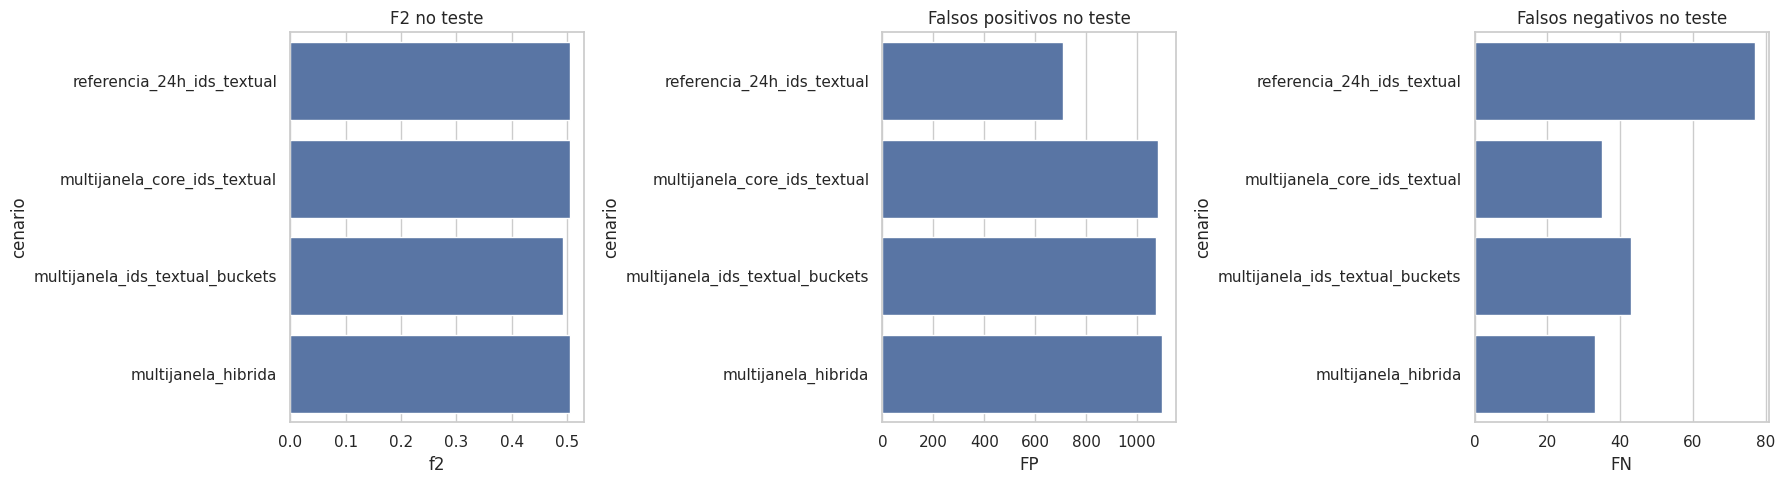

In [7]:
test_metrics = metrics[metrics["split"] == "teste"].copy()
val_metrics = metrics[metrics["split"] == "validacao"].copy()

print("Teste:")
display(test_metrics[[
    "cenario", "threshold", "pr_auc", "roc_auc", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "features", "tempo_s"
]].sort_values("f2", ascending=False))

print("Validação:")
display(val_metrics[[
    "cenario", "threshold", "pr_auc", "roc_auc", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "features"
]].sort_values("f2", ascending=False))

reference = test_metrics[test_metrics["cenario"] == "referencia_24h_ids_textual"].iloc[0]
delta_rows = []
for _, row in test_metrics.iterrows():
    delta_rows.append({
        "cenario": row["cenario"],
        "delta_pr_auc": row["pr_auc"] - reference["pr_auc"],
        "delta_precision": row["precision"] - reference["precision"],
        "delta_recall": row["recall"] - reference["recall"],
        "delta_f2": row["f2"] - reference["f2"],
        "delta_TP": row["TP"] - reference["TP"],
        "delta_FP": row["FP"] - reference["FP"],
        "delta_FN": row["FN"] - reference["FN"],
        "delta_TN": row["TN"] - reference["TN"],
    })
delta = pd.DataFrame(delta_rows).sort_values("delta_f2", ascending=False)
display(delta)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=test_metrics, y="cenario", x="f2", ax=axes[0])
axes[0].set(title="F2 no teste")
sns.barplot(data=test_metrics, y="cenario", x="FP", ax=axes[1])
axes[1].set(title="Falsos positivos no teste")
sns.barplot(data=test_metrics, y="cenario", x="FN", ax=axes[2])
axes[2].set(title="Falsos negativos no teste")
plt.tight_layout()
plt.show()

In [8]:
def summarize_group(df, group_cols):
    out = (
        df.assign(
            TP=(df["erro"] == "TP").astype(int),
            FP=(df["erro"] == "FP").astype(int),
            FN=(df["erro"] == "FN").astype(int),
            TN=(df["erro"] == "TN").astype(int),
        )
        .groupby(group_cols, dropna=False)
        .agg(
            amostras=("target", "size"),
            positivos_reais=("target", "sum"),
            positivos_previstos=("predito", "sum"),
            TP=("TP", "sum"),
            FP=("FP", "sum"),
            FN=("FN", "sum"),
            TN=("TN", "sum"),
            prob_media=("probabilidade", "mean"),
            prob_p90=("probabilidade", lambda x: x.quantile(.90)),
        )
        .reset_index()
    )
    out["precision"] = out["TP"] / (out["TP"] + out["FP"]).replace(0, np.nan)
    out["recall"] = out["TP"] / (out["TP"] + out["FN"]).replace(0, np.nan)
    out["taxa_fp"] = out["FP"] / (out["FP"] + out["TN"]).replace(0, np.nan)
    out["prevalencia"] = out["positivos_reais"] / out["amostras"]
    return out

tipo_audit = summarize_group(predictions, ["cenario", "Tipo"]).sort_values(["cenario", "Tipo"])
display(tipo_audit)

best_cenario = test_metrics.sort_values(["f2", "precision"], ascending=[False, False]).iloc[0]["cenario"]
best_pred = predictions[predictions["cenario"] == best_cenario].copy()
print(f"Melhor cenário no teste por F2: {best_cenario}")

print("Tags com mais FN no melhor cenário:")
display(
    summarize_group(best_pred, ["TAG", "Tipo"])
    .sort_values(["FN", "FP"], ascending=[False, False])
    .head(20)
)

print("Tags com mais FP no melhor cenário:")
display(
    summarize_group(best_pred, ["TAG", "Tipo"])
    .sort_values(["FP", "FN"], ascending=[False, False])
    .head(20)
)

print("Falsos negativos com menor probabilidade no melhor cenário:")
display(
    best_pred[best_pred["erro"] == "FN"]
    .sort_values("probabilidade")
    .head(20)
)

,cenario,Tipo,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
0,multijanela_core_ids_textual,Caminhao,2610,283,1330,250,1080,33,1247,0.173824,0.360959,0.187970,0.883392,0.464117,0.108429
1,multijanela_core_ids_textual,Escavadeira,435,2,2,0,2,2,431,0.016462,0.049427,0.000000,0.000000,0.004619,0.004598
2,multijanela_hibrida,Caminhao,2610,283,1350,252,1098,31,1229,0.172498,0.356493,0.186667,0.890459,0.471852,0.108429
3,multijanela_hibrida,Escavadeira,435,2,2,0,2,2,431,0.016345,0.044212,0.000000,0.000000,0.004619,0.004598
4,multijanela_ids_textual_buckets,Caminhao,2610,283,1315,242,1073,41,1254,0.176406,0.347612,0.184030,0.855124,0.461109,0.108429
5,multijanela_ids_textual_buckets,Escavadeira,435,2,2,0,2,2,431,0.017131,0.047515,0.000000,0.000000,0.004619,0.004598
6,referencia_24h_ids_textual,Caminhao,2610,283,918,208,710,75,1617,0.183102,0.395616,0.226580,0.734982,0.305114,0.108429
7,referencia_24h_ids_textual,Escavadeira,435,2,0,0,0,2,433,0.015545,0.036503,NaN,0.000000,0.000000,0.004598


Melhor cenário no teste por F2: multijanela_core_ids_textual
Tags com mais FN no melhor cenário:


,TAG,Tipo,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
16,CA65924,Caminhao,87,10,62,7,55,3,22,0.220060,0.461877,0.112903,0.700000,0.714286,0.114943
28,CA65936,Caminhao,87,23,74,20,54,3,10,0.196312,0.275250,0.270270,0.869565,0.843750,0.264368
27,CA65935,Caminhao,87,16,64,13,51,3,20,0.235758,0.494250,0.203125,0.812500,0.718310,0.183908
24,CA65932,Caminhao,87,9,53,6,47,3,31,0.271327,0.616193,0.113208,0.666667,0.602564,0.103448
29,CA65937,Caminhao,87,8,35,5,30,3,49,0.132723,0.225155,0.142857,0.625000,0.379747,0.091954
5,CA65792,Caminhao,87,12,84,10,74,2,1,0.305891,0.459308,0.119048,0.833333,0.986667,0.137931
13,CA65921,Caminhao,87,15,58,13,45,2,27,0.247963,0.512287,0.224138,0.866667,0.625000,0.172414
18,CA65926,Caminhao,87,53,82,51,31,2,3,0.419820,0.729809,0.621951,0.962264,0.911765,0.609195
2,CA65789,Caminhao,87,3,21,1,20,2,64,0.104898,0.188891,0.047619,0.333333,0.238095,0.034483
1,CA5927,Caminhao,87,14,71,13,58,1,15,0.252767,0.371443,0.183099,0.928571,0.794521,0.160920


Tags com mais FP no melhor cenário:


,TAG,Tipo,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
5,CA65792,Caminhao,87,12,84,10,74,2,1,0.305891,0.459308,0.119048,0.833333,0.986667,0.137931
1,CA5927,Caminhao,87,14,71,13,58,1,15,0.252767,0.371443,0.183099,0.928571,0.794521,0.160920
21,CA65929,Caminhao,87,1,58,1,57,0,29,0.160665,0.246947,0.017241,1.000000,0.662791,0.011494
16,CA65924,Caminhao,87,10,62,7,55,3,22,0.220060,0.461877,0.112903,0.700000,0.714286,0.114943
28,CA65936,Caminhao,87,23,74,20,54,3,10,0.196312,0.275250,0.270270,0.869565,0.843750,0.264368
25,CA65933,Caminhao,87,20,74,20,54,0,13,0.232516,0.420732,0.270270,1.000000,0.805970,0.229885
22,CA65930,Caminhao,87,6,58,5,53,1,28,0.171251,0.261634,0.086207,0.833333,0.654321,0.068966
11,CA65916,Caminhao,87,1,53,1,52,0,34,0.162781,0.251302,0.018868,1.000000,0.604651,0.011494
26,CA65934,Caminhao,87,2,54,2,52,0,33,0.160965,0.239551,0.037037,1.000000,0.611765,0.022989
27,CA65935,Caminhao,87,16,64,13,51,3,20,0.235758,0.494250,0.203125,0.812500,0.718310,0.183908


Falsos negativos com menor probabilidade no melhor cenário:


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,probabilidade,predito,erro
3112,PE3797,Escavadeira,LeTourneau L 1850,2025-06-01 08:00:00,2025-06-02 08:00:00,2025-06-02 16:00:00,1,multijanela_core_ids_textual,0.000000,0,FN
5700,PE3795,Escavadeira,LeTourneau L 1850,2025-06-26 00:00:00,2025-06-27 00:00:00,2025-06-27 08:00:00,1,multijanela_core_ids_textual,0.000000,0,FN
3133,CA65926,Caminhao,793-D 4S,2025-06-01 16:00:00,2025-06-02 16:00:00,2025-06-03 00:00:00,1,multijanela_core_ids_textual,0.027792,0,FN
3920,CA5926,Caminhao,793-D 5S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,1,multijanela_core_ids_textual,0.034423,0,FN
5592,CA65935,Caminhao,793-D 5S,2025-06-25 00:00:00,2025-06-26 00:00:00,2025-06-26 08:00:00,1,multijanela_core_ids_textual,0.050644,0,FN
5794,CA65927,Caminhao,793-D 5S,2025-06-27 00:00:00,2025-06-28 00:00:00,2025-06-28 08:00:00,1,multijanela_core_ids_textual,0.051669,0,FN
4612,CA65935,Caminhao,793-D 5S,2025-06-15 16:00:00,2025-06-16 16:00:00,2025-06-17 00:00:00,1,multijanela_core_ids_textual,0.061162,0,FN
5968,CA65926,Caminhao,793-D 4S,2025-06-28 16:00:00,2025-06-29 16:00:00,2025-06-30 00:00:00,1,multijanela_core_ids_textual,0.062262,0,FN
4275,CA65792,Caminhao,793-D 2S,2025-06-12 16:00:00,2025-06-13 16:00:00,2025-06-14 00:00:00,1,multijanela_core_ids_textual,0.074391,0,FN
5648,CA65921,Caminhao,793-D 4S,2025-06-25 16:00:00,2025-06-26 16:00:00,2025-06-27 00:00:00,1,multijanela_core_ids_textual,0.079408,0,FN


## 7. Leitura esperada

Registrar após execução:

1. se alguma multijanela superou a referência em validação e teste;
2. se o ganho veio de redução de FP, redução de FN ou apenas deslocamento de threshold;
3. se escavadeiras tiveram qualquer predição positiva real;
4. se o melhor cenário no teste também é defensável na validação;
5. se a complexidade adicional das features por bucket justifica o ganho observado.

Decisão só deve ser consolidada após comparar o melhor cenário com a referência 24h agregada, evitando
troca baseada apenas em teste isolado.